# Universidad Autónoma de Aguascalientes

# Departamento: Ciencias de la Computación

# Carrera: Ingeniería en Computación Inteligente

## Curso: Aprendizaje Automático

## Maestro: Dr. Francisco Javier Luna Rosas

## Alumno: Carlos Leonardo Cruz Ortiz

### Semestre: Enero-Junio del 2026

# PRACTICA 8. REDES NEURONALES (SCIKIT-LEARN_MLPCLASSIFIER) PARA IMPLEMENTAR LAS SIGUIENTES FORMAS DE ENTRENAMIENTO: TABLA-TESTING, TABLA-COMPLETA, LOOCV Y K-FOLDS
### En esta práctica se analizará diferentes formas de evaluación para modelos de clasificación con redes neuronales. Compararemos cuatro métodos de evaluación: Tabla Testing (split 70/30), Tabla Completa (entrenar y evaluar con todos los datos), LOOCV (Leave-One-Out Cross Validation) y K-Fold Cross Validation.

## Paso 1: Importar librerías necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, LeaveOneOut, KFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

## Paso 2: Cargamos el dataset de Iris

In [2]:
df = pd.read_csv('../data/iris.csv', delimiter=';', decimal='.')
print(df.shape)
print(df.head())

(150, 5)
   s.largo  s.ancho  p.largo  p.ancho    tipo
0      5.1      3.5      1.4      0.2  setosa
1      4.9      3.0      1.4      0.2  setosa
2      4.7      3.2      1.3      0.2  setosa
3      4.6      3.1      1.5      0.2  setosa
4      5.0      3.6      1.4      0.2  setosa


## Paso 3: Separar variables predictoras (X) y variable objetivo (y)

In [ ]:
X = df.iloc[:, :4].values
print("Shape de X:", X.shape)

# Variable objetivo (última columna)
y = df.iloc[:, 4].values
print("Shape de y:", y.shape)

Shape de X: (150, 4)
Shape de y: (150,)
Clases: ['setosa' 'versicolor' 'virginica']


## Paso 4: Método 1 - Tabla Testing (split 70/30)
### Dividimos los datos en 70% entrenamiento y 30% testing para evaluar el modelo

In [ ]:
def evaluacion_tabla_testing(X, y, n_iteraciones=10):
  """
  Evalúa el modelo usando división train/test (70/30).

  :param X: Variables predictoras
  :param y: Variable objetivo
  :param int n_iteraciones: Número de iteraciones a ejecutar
  :return: Lista de errores por iteración
  """
  errores = []

  for i in range(n_iteraciones):
    X_train, X_test, y_train, y_test = train_test_split(
      X, y, train_size=0.7, random_state=i
    )

    # Crear y entrenar el modelo
    modelo = MLPClassifier(max_iter=500, random_state=i)
    modelo.fit(X_train, y_train)

    # Predecir y calcular error
    y_pred = modelo.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    error = 1 - accuracy
    errores.append(error)

    if i == 0:
      print(f"Iteración {i+1}: Accuracy = {accuracy:.4f}, Error = {error:.4f}")

  print(f"\nError promedio (Tabla Testing): {np.mean(errores):.4f}")
  print(f"Desviación estándar: {np.std(errores):.4f}")
  return errores


errores_testing = evaluacion_tabla_testing(X, y, n_iteraciones=10)

Iteración 1: Accuracy = 0.9778, Error = 0.0222

Error promedio (Tabla Testing): 0.0178
Desviación estándar: 0.0133


## Paso 5: Método 2 - Tabla Completa
### Entrenamos y evaluamos con todos los datos (mismo conjunto para train y test)

In [ ]:
def evaluacion_tabla_completa(X, y, n_iteraciones=10):
  """
  Evalúa el modelo entrenando y evaluando con todos los datos.

  :param X: Variables predictoras
  :param y: Variable objetivo
  :param int n_iteraciones: Número de iteraciones a ejecutar
  :return: Lista de errores por iteración
  """
  errores = []

  for i in range(n_iteraciones):
    modelo = MLPClassifier(max_iter=500, random_state=i)
    modelo.fit(X, y)

    # Predecir con los mismos datos de entrenamiento
    y_pred = modelo.predict(X)
    accuracy = accuracy_score(y, y_pred)
    error = 1 - accuracy
    errores.append(error)

    if i == 0:
      print(f"Iteración {i+1}: Accuracy = {accuracy:.4f}, Error = {error:.4f}")

  print(f"\nError promedio (Tabla Completa): {np.mean(errores):.4f}")
  print(f"Desviación estándar: {np.std(errores):.4f}")
  return errores


errores_completa = evaluacion_tabla_completa(X, y, n_iteraciones=10)

Iteración 1: Accuracy = 0.9800, Error = 0.0200

Error promedio (Tabla Completa): 0.0207
Desviación estándar: 0.0020


## Paso 6: Método 3 - LOOCV (Leave-One-Out Cross Validation)
### Validación cruzada dejando un dato fuera en cada iteración

In [ ]:
def evaluacion_loocv(X, y, n_iteraciones=10):
  """
  Evalúa el modelo usando Leave-One-Out Cross Validation.

  :param X: Variables predictoras
  :param y: Variable objetivo
  :param int n_iteraciones: Número de iteraciones a ejecutar
  :return: Lista de errores por iteración
  """
  errores = []
  loo = LeaveOneOut()

  for i in range(n_iteraciones):
    predicciones_correctas = 0
    total_predicciones = 0

    # Para cada fold de LOOCV
    for train_index, test_index in loo.split(X):
      X_train, X_test = X[train_index], X[test_index]
      y_train, y_test = y[train_index], y[test_index]

      modelo = MLPClassifier(max_iter=500, random_state=i)
      modelo.fit(X_train, y_train)

      # Predecir
      y_pred = modelo.predict(X_test)
      predicciones_correctas += (y_pred == y_test).sum()
      total_predicciones += len(y_test)

    accuracy = predicciones_correctas / total_predicciones
    error = 1 - accuracy
    errores.append(error)

    if i == 0:
      print(f"Iteración {i+1}: Accuracy = {accuracy:.4f}, Error = {error:.4f}")

  print(f"\nError promedio (LOOCV): {np.mean(errores):.4f}")
  print(f"Desviación estándar: {np.std(errores):.4f}")
  return errores


errores_loocv = evaluacion_loocv(X, y, n_iteraciones=10)

Iteración 1: Accuracy = 0.9733, Error = 0.0267

Error promedio (LOOCV): 0.0273
Desviación estándar: 0.0020


## Paso 7: Método 4 - K-Fold Cross Validation (K-ésimo grupo)
### Validación cruzada dejando k datos fuera en cada iteración (usaremos k=5)

In [ ]:
def evaluacion_kfold(X, y, n_iteraciones=10, k=5):
  """
  Evalúa el modelo usando K-Fold Cross Validation.

  :param X: Variables predictoras
  :param y: Variable objetivo
  :param int n_iteraciones: Número de iteraciones a ejecutar
  :param int k: Número de folds
  :return: Lista de errores por iteración
  """
  errores = []

  for i in range(n_iteraciones):
    kfold = KFold(n_splits=k, shuffle=True, random_state=i)
    predicciones_correctas = 0
    total_predicciones = 0

    # Para cada fold
    for train_index, test_index in kfold.split(X):
      X_train, X_test = X[train_index], X[test_index]
      y_train, y_test = y[train_index], y[test_index]

      modelo = MLPClassifier(max_iter=500, random_state=i)
      modelo.fit(X_train, y_train)

      # Predecir
      y_pred = modelo.predict(X_test)
      predicciones_correctas += (y_pred == y_test).sum()
      total_predicciones += len(y_test)

    accuracy = predicciones_correctas / total_predicciones
    error = 1 - accuracy
    errores.append(error)

    if i == 0:
      print(f"Iteración {i+1} (K={k}): Accuracy = {accuracy:.4f}, Error = {error:.4f}")

  print(f"\nError promedio (K-Fold, K={k}): {np.mean(errores):.4f}")
  print(f"Desviación estándar: {np.std(errores):.4f}")
  return errores


errores_kfold = evaluacion_kfold(X, y, n_iteraciones=10, k=5)

Iteración 1 (K=5): Accuracy = 0.9733, Error = 0.0267

Error promedio (K-Fold, K=5): 0.0240
Desviación estándar: 0.0053


## Paso 8: Resumen de resultados

In [ ]:
# Crear DataFrame con los resultados
resultados = pd.DataFrame({
  'Iteración': range(1, 11),
  'Tabla Testing': errores_testing,
  'Tabla Completa': errores_completa,
  'LOOCV': errores_loocv,
  'K-Fold (K=5)': errores_kfold
})

print("\n" + "="*80)
print("TABLA DE RESULTADOS - ERRORES POR MÉTODO DE EVALUACIÓN")
print("="*80)
print(resultados.to_string(index=False))

print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*80)
print(resultados.describe().loc[['mean', 'std', 'min', 'max']].to_string())


TABLA DE RESULTADOS - ERRORES POR MÉTODO DE EVALUACIÓN
 Iteración  Tabla Testing  Tabla Completa    LOOCV  K-Fold (K=5)
         1       0.022222        0.020000 0.026667      0.026667
         2       0.000000        0.020000 0.026667      0.020000
         3       0.000000        0.020000 0.026667      0.033333
         4       0.044444        0.020000 0.033333      0.033333
         5       0.022222        0.020000 0.026667      0.020000
         6       0.022222        0.020000 0.026667      0.020000
         7       0.022222        0.020000 0.026667      0.026667
         8       0.022222        0.020000 0.026667      0.020000
         9       0.022222        0.026667 0.026667      0.020000
        10       0.000000        0.020000 0.026667      0.020000

ESTADÍSTICAS DESCRIPTIVAS
      Iteración  Tabla Testing  Tabla Completa     LOOCV  K-Fold (K=5)
mean    5.50000       0.017778        0.020667  0.027333      0.024000
std     3.02765       0.014055        0.002108  0.002108    

## Paso 9: Gráfica de Variación del Error
### Visualización comparativa de los errores en las 10 iteraciones

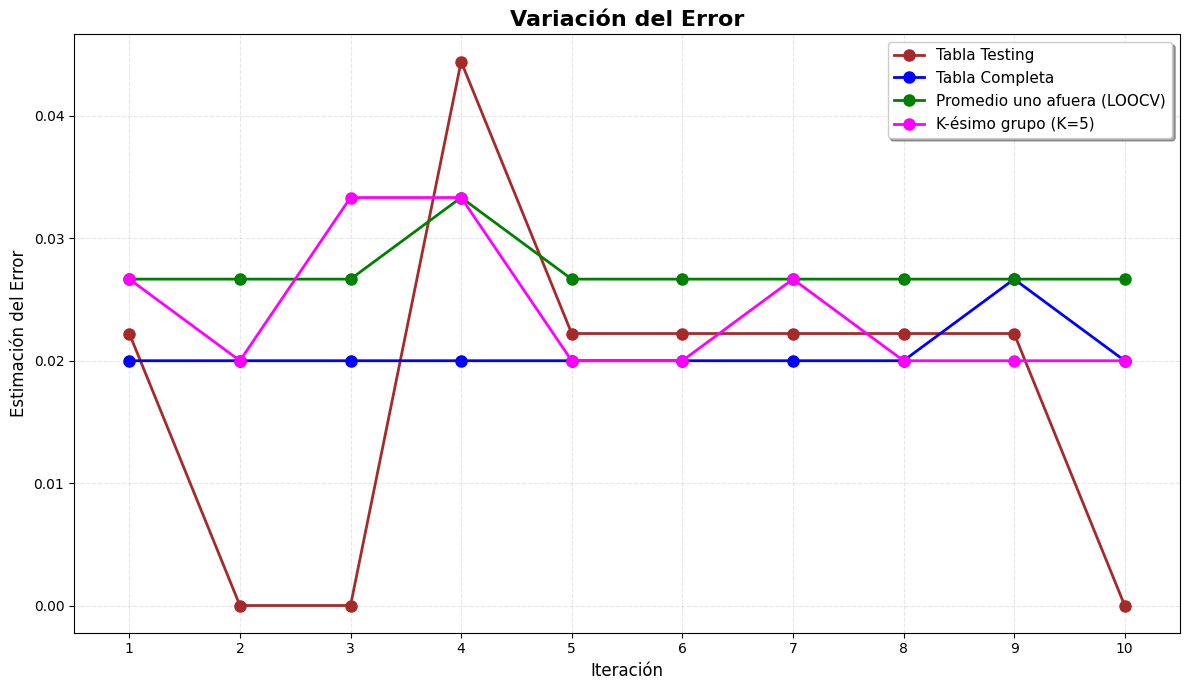


Gráfica generada exitosamente.


In [ ]:
plt.figure(figsize=(12, 7))

iteraciones = range(1, 11)

plt.plot(iteraciones, errores_testing, 'o-', color='brown', 
         label='Tabla Testing', linewidth=2, markersize=8)
plt.plot(iteraciones, errores_completa, 'o-', color='blue', 
         label='Tabla Completa', linewidth=2, markersize=8)
plt.plot(iteraciones, errores_loocv, 'o-', color='green', 
         label='Promedio uno afuera (LOOCV)', linewidth=2, markersize=8)
plt.plot(iteraciones, errores_kfold, 'o-', color='magenta', 
         label='K-ésimo grupo (K=5)', linewidth=2, markersize=8)

# Configurar títulos y etiquetas
plt.title('Variación del Error', fontsize=16, fontweight='bold')
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Estimación del Error', fontsize=12)

plt.legend(loc='best', fontsize=11, frameon=True, shadow=True)

plt.grid(True, alpha=0.3, linestyle='--')

plt.xlim(0.5, 10.5)
plt.xticks(iteraciones)

plt.tight_layout()
plt.show()

print("\nGráfica generada exitosamente.")

## Conclusiones

### En esta práctica se implemento y comparo cuatro formas de evaluación para un modelo de clasificación con MLPClassifier. Se observó que cada método tiene sus ventajas y desventajas en términos de sesgo, varianza y tiempo de cómputo. La gráfica comparativa nos permitió visualizar claramente las diferencias en el rendimiento del modelo bajo cada método de evaluación.

## Referencias

### SCIKIT-LEARN (Machine Learning in Python 2025). MLPClassifier. URL: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html (Último acceso febrero 2025).
### SCIKIT-LEARN (Machine Learning in Python 2025). Cross-validation. URL: https://scikit-learn.org/stable/modules/cross_validation.html (Último acceso febrero 2025).